In [26]:
import pandas as pd
import yaml
import geodatasets
import geopandas as gpd
import math
import rasterio
import os
import openpyxl
import pygwalker as pyg
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import re
import sys
import textwrap
from shapely.geometry import Point
from datetime import datetime
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from matplotlib.transforms import blended_transform_factory
from matplotlib.gridspec import GridSpec
from io import BytesIO
from IPython.display import Image, display as ipy_display
from rasterio.windows import Window
from tqdm.notebook import tqdm
from dask.distributed import Client, as_completed

In [27]:
# To add project files
# Keeps going up project structure until it gets to the root.
# Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69a5ff07-91e0-8329-88d1-cf2ea6c159c2
project_root = Path().resolve()
while project_root.name != "AFOLU_GHG_flux_model":
    project_root = project_root.parent

sys.path.append(str(project_root))

from src.utilities import constants_and_names as cn
from src.utilities import universal_utilities as uu
from src.utilities.create_cluster import create_cluster as cc_create_cluster

now = datetime.now()
today = now.strftime("%Y%m%d")

pd.set_option('display.max_columns', None)

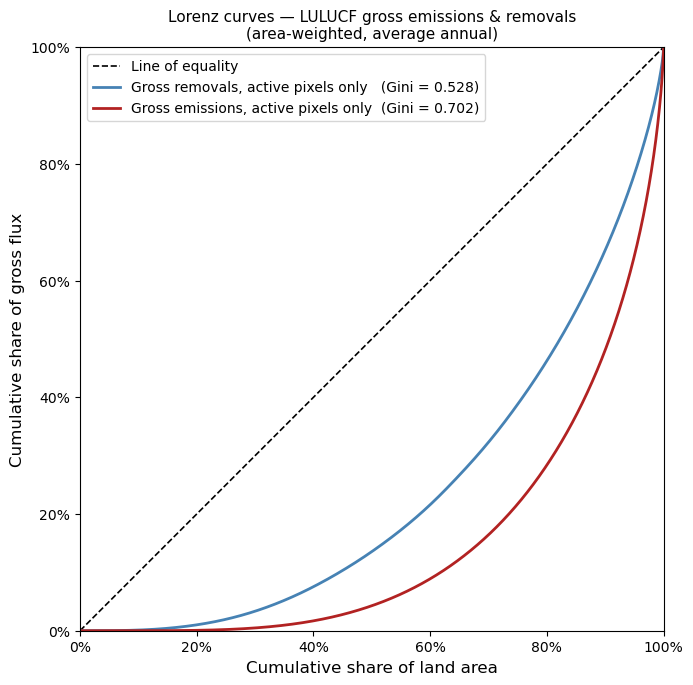

Zero-flux pixels added (emissions scenario): 1,667,536
Zero-flux pixels added (removals scenario):  1,752,487
VALIDATION SUMMARY

Pixel size: 8.4875 km²

Pixel counts (emissions grid as reference):
  Total pixels          :     53,118,450
  Nodata (== 0)         :     43,669,078  (82.2%)
  Emitting  (> 0)       :      9,449,372  (17.8%)
  Removing  (< 0)       :      9,930,760  (18.7%)

Land area covered:
  Emitting land         :      80.20 Mkm²
  Removing land         :      84.29 Mkm²

Total fluxes  ← compare against known model output:
  Gross emissions       :     30.212 GtCO2e/yr
  Gross removals        :     39.180 GtCO2e/yr
  Net (emis − remv)     :     -8.968 GtCO2e/yr

Concentration — emissions:
  Top 10% most intensive land → 51.9% of gross emissions
  Top 25% most intensive land → 78.3% of gross emissions
  Top 50% most intensive land → 95.7% of gross emissions

Concentration — removals:
  Top 10% most intensive land → 34.8% of gross removals
  Top 25% most intensive land →

In [3]:
### Lorenz curves of average annual LULUCF gross emissions and gross removals using the aggregated (roughly 4km) outputs
### x-axis is cumulative share of area in each map; y-axis is the cumulative gross emissions and gross removals
### Per Claude session Lorenz curves for LULUCF emissions/removals

# ── File paths ────────────────────────────────────────────────────────────
base_dir = "/mnt/c/GIS/AFOLU_flux_model/LULUCF/4x4km_aggregated_maps/LULUCF_totals/veg_v1_0_5_standard_global__org_soil_v_1_0_0__min_soil_v_1_0_0"
# emis_path = f"{base_dir}/LULUCF_gross_emis__veg_v1_0_5___organic_soil_v1_0_0_mineral_soil_v1_0_0__MgCO2e_yr.tif"
# remv_path = f"{base_dir}/LULUCF_gross_remv__veg_v1_0_5___organic_soil_v1_0_0_mineral_soil_v1_0_0__MgCO2e_yr.tif"

emis_path = f"{base_dir}/LULUCF_gross_emis__veg_v1_0_5___organic_soil_v1_0_0_mineral_soil_v1_0_0__MgCO2e_yr__forest_ecozones_only.tif"
remv_path = f"{base_dir}/LULUCF_gross_remv__veg_v1_0_5___organic_soil_v1_0_0_mineral_soil_v1_0_0__MgCO2e_yr__forest_ecozones_only.tif"

# ── Load rasters ──────────────────────────────────────────────────────────
with rasterio.open(emis_path) as src:
    emis_grid = src.read(1).astype(np.float64)
    pixel_area_km2 = abs(src.transform.a * src.transform.e) / 1e6  # m² → km²

with rasterio.open(remv_path) as src:
    remv_grid = src.read(1).astype(np.float64)

# ── Extract valid pixels (nodata == 0) ────────────────────────────────────
emis_mask = emis_grid > 0
remv_mask = remv_grid < 0

emis_vals  = emis_grid[emis_mask]            # MgCO2e/pixel/yr, positive
remv_vals  = np.abs(remv_grid[remv_mask])    # MgCO2e/pixel/yr, magnitude

n_emis = emis_mask.sum()
n_remv = remv_mask.sum()

# ── Lorenz curve (with optional zero-flux land padding) ───────────────────
def lorenz_curve(flux_vals, zero_land_frac=0.0):
    """
    zero_land_frac: fraction of *total* land area that has zero flux.
    Those pixels sort to the front. Sahara latitude ignored since pixel
    area is constant in Robinson projection.
    """
    n_active = len(flux_vals)
    n_zeros  = round(zero_land_frac / (1.0 - zero_land_frac) * n_active)
    n_total  = n_active + n_zeros

    sorted_flux = np.concatenate([np.zeros(n_zeros), np.sort(flux_vals)])
    cum_area = np.arange(n_total + 1, dtype=np.float64) / n_total
    cum_flux = np.concatenate([[0.0], np.cumsum(sorted_flux)])
    cum_flux /= cum_flux[-1]
    return cum_area, cum_flux

def gini(x, y):
    return 1.0 - 2.0 * np.trapezoid(y, x)

emis_x,  emis_y  = lorenz_curve(emis_vals)
emis_xz, emis_yz = lorenz_curve(emis_vals, zero_land_frac=0.15)
remv_x,  remv_y  = lorenz_curve(remv_vals)
remv_xz, remv_yz = lorenz_curve(remv_vals, zero_land_frac=0.15)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Line of equality')

ax.plot(remv_x,  remv_y,  color='steelblue', lw=2, linestyle='-',
        label=f'Gross removals, active pixels only   (Gini = {gini(remv_x, remv_y):.3f})')
# ax.plot(remv_xz, remv_yz, color='steelblue', lw=2, linestyle=':',
#         label=f'Gross removals, +15% zero-flux land  (Gini = {gini(remv_xz, remv_yz):.3f})')
ax.plot(emis_x,  emis_y,  color='firebrick', lw=2, linestyle='-',
        label=f'Gross emissions, active pixels only  (Gini = {gini(emis_x, emis_y):.3f})')
# ax.plot(emis_xz, emis_yz, color='firebrick', lw=2, linestyle=':',
#         label=f'Gross emissions, +15% zero-flux land (Gini = {gini(emis_xz, emis_yz):.3f})')

ax.set_xlabel('Cumulative share of land area', fontsize=12)
ax.set_ylabel('Cumulative share of gross flux', fontsize=12)
ax.set_title(
    'Lorenz curves — LULUCF gross emissions & removals\n(area-weighted, average annual)',
    fontsize=11
)
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print(f"Zero-flux pixels added (emissions scenario): {round(0.15/0.85 * n_emis):,}")
print(f"Zero-flux pixels added (removals scenario):  {round(0.15/0.85 * n_remv):,}")

# ── Validation ────────────────────────────────────────────────────────────
n_total  = emis_grid.size
n_nodata = int(np.sum(emis_grid == 0))

print("=" * 57)
print("VALIDATION SUMMARY")
print("=" * 57)

print(f"\nPixel size: {pixel_area_km2:.4f} km²")

print(f"\nPixel counts (emissions grid as reference):")
print(f"  Total pixels          : {n_total:>14,}")
print(f"  Nodata (== 0)         : {n_nodata:>14,}  ({100*n_nodata/n_total:.1f}%)")
print(f"  Emitting  (> 0)       : {n_emis:>14,}  ({100*n_emis/n_total:.1f}%)")
print(f"  Removing  (< 0)       : {n_remv:>14,}  ({100*n_remv/n_total:.1f}%)")

print(f"\nLand area covered:")
print(f"  Emitting land         : {n_emis * pixel_area_km2 / 1e6:>10.2f} Mkm²")
print(f"  Removing land         : {n_remv * pixel_area_km2 / 1e6:>10.2f} Mkm²")

print(f"\nTotal fluxes  ← compare against known model output:")
print(f"  Gross emissions       : {emis_vals.sum()/1e9:>10.3f} GtCO2e/yr")
print(f"  Gross removals        : {remv_vals.sum()/1e9:>10.3f} GtCO2e/yr")
print(f"  Net (emis − remv)     : {(emis_vals.sum()-remv_vals.sum())/1e9:>10.3f} GtCO2e/yr")

print(f"\nConcentration — emissions:")
for pct in [10, 25, 50]:
    idx = np.searchsorted(emis_x, 1 - pct / 100)
    print(f"  Top {pct:2d}% most intensive land → {100*(1-emis_y[idx]):.1f}% of gross emissions")

print(f"\nConcentration — removals:")
for pct in [10, 25, 50]:
    idx = np.searchsorted(remv_x, 1 - pct / 100)
    print(f"  Top {pct:2d}% most intensive land → {100*(1-remv_y[idx]):.1f}% of gross removals")

print(f"\nGini coefficients:")
print(f"  Gross emissions       : {gini(emis_x, emis_y):.4f}")
print(f"  Gross removals        : {gini(remv_x,  remv_y):.4f}")

print(f"\nCurve endpoint check (should both be exactly 1.0):")
print(f"  Emissions             : x={emis_x[-1]:.6f},  y={emis_y[-1]:.6f}")
print(f"  Removals              : x={remv_x[-1]:.6f},  y={remv_y[-1]:.6f}")

Bbox   : W=13 S=-3 E=15 N=-1
Tile   : 00N_010E
Window : col 12000–20000, row 4000–12000 (8000×8000 px = 64,000,000 pixels)
Reading emissions...
Reading removals...


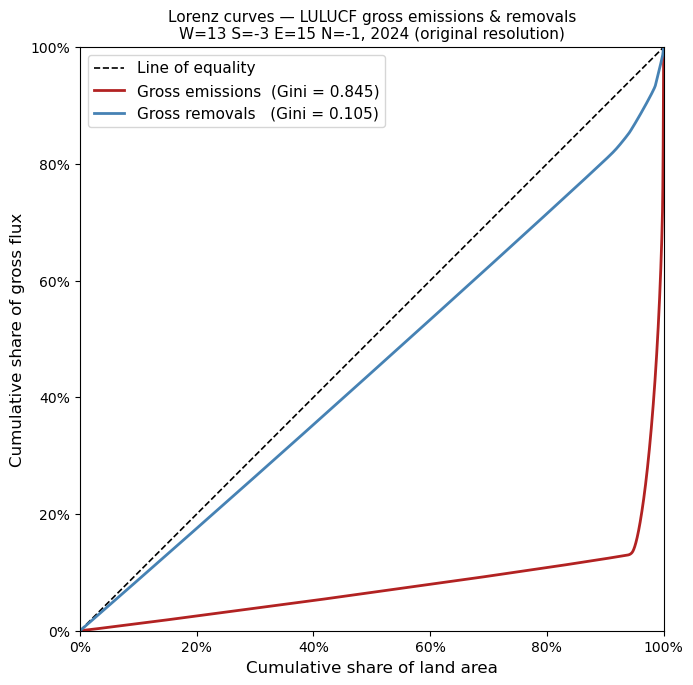

VALIDATION SUMMARY

Bbox  : W=13 S=-3 E=15 N=-1
Tile  : 00N_010E,  Year: 2024

Pixel counts:
  Total pixels          :     64,000,000
  Nodata (== 0)         :     48,018,935  (75.0%)
  Emitting  (> 0)       :     15,981,065  (25.0%)
  Removing  (< 0)       :     32,129,832  (50.2%)

Land area covered:
  Emitting land         :     0.0123 Mkm²
  Removing land         :     0.0248 Mkm²

Total fluxes:
  Gross emissions       :   0.004196 GtCO2e/yr
  Gross removals        :   0.007564 GtCO2e/yr
  Net (emis − remv)     :  -0.003368 GtCO2e/yr

Concentration — emissions:
  Top 10% most intensive → 87.7% of gross emissions
  Top 25% most intensive → 89.9% of gross emissions
  Top 50% most intensive → 93.4% of gross emissions

Concentration — removals:
  Top 10% most intensive → 19.3% of gross removals
  Top 25% most intensive → 33.1% of gross removals
  Top 50% most intensive → 55.7% of gross removals

Gini coefficients:
  Gross emissions       : 0.8448
  Gross removals        : 0.1054

Curve

In [28]:
### Lorenz curves of average annual LULUCF gross emissions and gross removals using the original resolution (0.00025 deg) outputs
### x-axis is cumulative share of area in each map; y-axis is the cumulative gross emissions and gross removals
### Per Claude session `Lorenz curves for LULUCF emissions/removals` and 'Lorenz curves for LULUCF emissions/removals, pt2' 

### Test on a 1x1 deg window from a 10x10 deg Amazon tile
### Northwest corner naming convention; per-pixel flux values already geodesic-area-corrected

# ── Configuration ─────────────────────────────────────────────────────────
# BBOX_W, BBOX_S, BBOX_E, BBOX_N = -67.0, 5.0, -65.0, 7.0   # W S E N (Colombian Amazon)
BBOX_W, BBOX_S, BBOX_E, BBOX_N = 13, -3, 15, -1   # W S E N (Central Africa)
# BBOX_W, BBOX_S, BBOX_E, BBOX_N = 113, -3, 115, -1   # W S E N (Borneo)
# BBOX_W, BBOX_S, BBOX_E, BBOX_N = 107, 58, 109, 60   # W S E N (Siberian fires)
# BBOX_W, BBOX_S, BBOX_E, BBOX_N = 114, 58, 116, 60   # W S E N (Siberian minimal fires)
YEAR = 2024
PIXELS_PER_DEG = 4000   # 0.00025 deg/pixel

# ── Derive tile and window from bbox ──────────────────────────────────────
def bbox_to_tile_and_window(w, s, e, n, pixels_per_deg):
    tile_north = math.ceil(n  / 10) * 10
    tile_west  = math.floor(w / 10) * 10
    lat_str = f"{abs(tile_north):02d}{'N' if tile_north >= 0 else 'S'}"
    lon_str = f"{abs(tile_west):03d}{'E' if tile_west  >= 0 else 'W'}"
    tile = f"{lat_str}_{lon_str}"
    col_off = round((w - tile_west)  * pixels_per_deg)
    row_off = round((tile_north - n) * pixels_per_deg)
    width   = round((e - w)          * pixels_per_deg)
    height  = round((n - s)          * pixels_per_deg)
    assert col_off >= 0 and row_off >= 0, "Bbox extends beyond tile north/west edge"
    assert col_off + width  <= 10 * pixels_per_deg, "Bbox extends beyond tile east edge"
    assert row_off + height <= 10 * pixels_per_deg, "Bbox extends beyond tile south edge"
    return tile, tile_north, tile_west, Window(col_off, row_off, width, height)

TILE, TILE_NORTH, TILE_WEST, window = bbox_to_tile_and_window(
    BBOX_W, BBOX_S, BBOX_E, BBOX_N, PIXELS_PER_DEG
)

print(f"Bbox   : W={BBOX_W} S={BBOX_S} E={BBOX_E} N={BBOX_N}")
print(f"Tile   : {TILE}")
print(f"Window : col {window.col_off}–{window.col_off+window.width}, "
      f"row {window.row_off}–{window.row_off+window.height} "
      f"({window.width}×{window.height} px = {window.width*window.height:,} pixels)")

# ── S3 paths ──────────────────────────────────────────────────────────────
BASE = "s3://gfw2-data/climate/AFOLU_flux_model/LULUCF/outputs_vegetation/version_1_0_5__standard__global"
EMIS_S3 = (f"{BASE}/gross_emissions__all_C_pools__all_gases__MgCO2e/"
           f"annual_intervals/{YEAR}/_pixel_yr/40000_pixels/20260130/"
           f"{TILE}__gross_emissions__all_C_pools__all_gases__MgCO2e_pixel_yr_{YEAR}.tif")
REMV_S3 = (f"{BASE}/gross_removals__all_C_pools__MgCO2/"
           f"annual_intervals/{YEAR}/_pixel_yr/40000_pixels/20260130/"
           f"{TILE}__gross_removals__all_C_pools__MgCO2_pixel_yr_{YEAR}.tif")

# ── Pixel area grid (km²) from latitude ───────────────────────────────────
def pixel_area_grid_wgs84(src, window):
    t = src.transform
    row_idx     = np.arange(window.row_off, window.row_off + window.height)
    lat_centers = t.f + (row_idx + 0.5) * t.e
    d_lat_rad   = abs(t.e) * np.pi / 180
    d_lon_rad   = abs(t.a) * np.pi / 180
    areas_1d    = 6371.0**2 * d_lat_rad * d_lon_rad * np.cos(np.deg2rad(lat_centers))
    return np.broadcast_to(
        areas_1d[:, np.newaxis], (window.height, window.width)
    ).copy()

# ── Load window from S3 ───────────────────────────────────────────────────
print("Reading emissions...")
with rasterio.open(EMIS_S3) as src:
    emis_grid = src.read(1, window=window).astype(np.float64)
    area_grid = pixel_area_grid_wgs84(src, window)

print("Reading removals...")
with rasterio.open(REMV_S3) as src:
    remv_grid = src.read(1, window=window).astype(np.float64)

# ── Mask valid pixels (nodata == 0) ───────────────────────────────────────
emis_mask  = emis_grid > 0
remv_mask  = remv_grid < 0
emis_vals  = emis_grid[emis_mask]
emis_areas = area_grid[emis_mask]
remv_vals  = np.abs(remv_grid[remv_mask])
remv_areas = area_grid[remv_mask]

# ── Lorenz curve ──────────────────────────────────────────────────────────
def lorenz_curve(flux_vals, area_vals):
    intensity = flux_vals / area_vals
    idx      = np.argsort(intensity)
    cum_area = np.concatenate([[0.0], np.cumsum(area_vals[idx])])
    cum_flux = np.concatenate([[0.0], np.cumsum(flux_vals[idx])])
    return cum_area / cum_area[-1], cum_flux / cum_flux[-1]

def gini(x, y):
    return 1.0 - 2.0 * np.trapezoid(y, x)

emis_x, emis_y = lorenz_curve(emis_vals, emis_areas)
remv_x,  remv_y = lorenz_curve(remv_vals,  remv_areas)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Line of equality')
ax.plot(emis_x, emis_y, color='firebrick', lw=2,
        label=f'Gross emissions  (Gini = {gini(emis_x, emis_y):.3f})')
ax.plot(remv_x,  remv_y, color='steelblue', lw=2,
        label=f'Gross removals   (Gini = {gini(remv_x, remv_y):.3f})')

ax.set_xlabel('Cumulative share of land area', fontsize=12)
ax.set_ylabel('Cumulative share of gross flux', fontsize=12)
ax.set_title(
    f'Lorenz curves — LULUCF gross emissions & removals\n'
    f'W={BBOX_W} S={BBOX_S} E={BBOX_E} N={BBOX_N}, {YEAR} (original resolution)',
    fontsize=11
)
ax.legend(fontsize=11, loc='upper left')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

# ── Validation ────────────────────────────────────────────────────────────
n_total  = emis_grid.size
n_nodata = int(np.sum(emis_grid == 0))
n_emis   = emis_mask.sum()
n_remv   = remv_mask.sum()

print("=" * 57)
print("VALIDATION SUMMARY")
print("=" * 57)
print(f"\nBbox  : W={BBOX_W} S={BBOX_S} E={BBOX_E} N={BBOX_N}")
print(f"Tile  : {TILE},  Year: {YEAR}")

print(f"\nPixel counts:")
print(f"  Total pixels          : {n_total:>14,}")
print(f"  Nodata (== 0)         : {n_nodata:>14,}  ({100*n_nodata/n_total:.1f}%)")
print(f"  Emitting  (> 0)       : {n_emis:>14,}  ({100*n_emis/n_total:.1f}%)")
print(f"  Removing  (< 0)       : {n_remv:>14,}  ({100*n_remv/n_total:.1f}%)")

print(f"\nLand area covered:")
print(f"  Emitting land         : {emis_areas.sum()/1e6:>10.4f} Mkm²")
print(f"  Removing land         : {remv_areas.sum()/1e6:>10.4f} Mkm²")

print(f"\nTotal fluxes:")
print(f"  Gross emissions       : {emis_vals.sum()/1e9:>10.6f} GtCO2e/yr")
print(f"  Gross removals        : {remv_vals.sum()/1e9:>10.6f} GtCO2e/yr")
print(f"  Net (emis − remv)     : {(emis_vals.sum()-remv_vals.sum())/1e9:>10.6f} GtCO2e/yr")

print(f"\nConcentration — emissions:")
for pct in [10, 25, 50]:
    idx = np.searchsorted(emis_x, 1 - pct / 100)
    print(f"  Top {pct:2d}% most intensive → {100*(1-emis_y[idx]):.1f}% of gross emissions")

print(f"\nConcentration — removals:")
for pct in [10, 25, 50]:
    idx = np.searchsorted(remv_x, 1 - pct / 100)
    print(f"  Top {pct:2d}% most intensive → {100*(1-remv_y[idx]):.1f}% of gross removals")

print(f"\nGini coefficients:")
print(f"  Gross emissions       : {gini(emis_x, emis_y):.4f}")
print(f"  Gross removals        : {gini(remv_x,  remv_y):.4f}")

print(f"\nCurve endpoint check (should both be exactly 1.0):")
print(f"  Emissions             : x={emis_x[-1]:.6f},  y={emis_y[-1]:.6f}")
print(f"  Removals              : x={remv_x[-1]:.6f},  y={remv_y[-1]:.6f}")

Chunks to process: 4


Processing chunks (2024):   0%|          | 0/4 [00:00<?, ?it/s]

Done — processed: 4  |  missing/skipped: 0


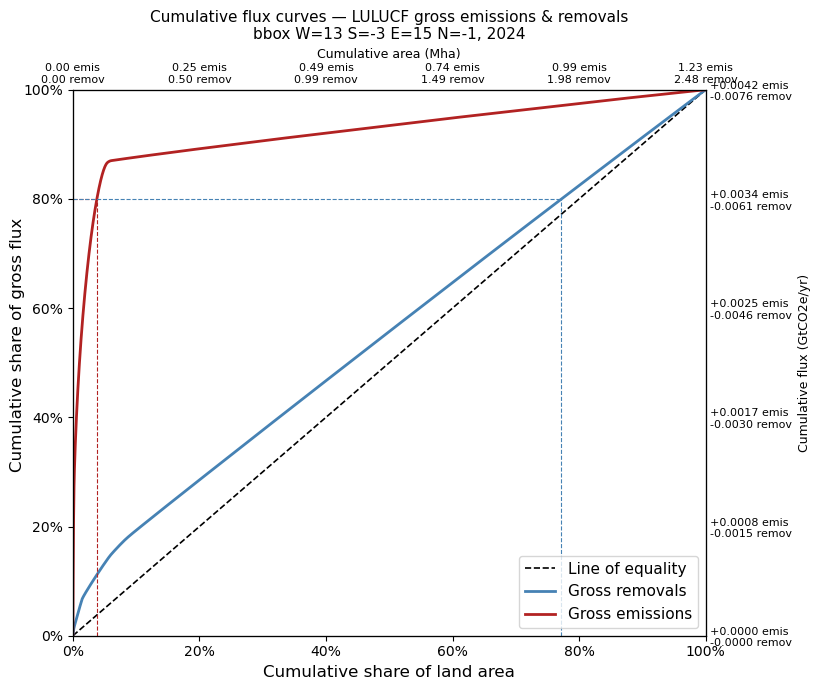

VALIDATION SUMMARY

Year             : 2024
Chunks processed : 4  |  missing: 0
Histogram bins   : 10,000  (log 1e-06–1e+05 MgCO2e/ha/yr)

Land area covered:
  Emitting land         :       1.23 Mha
  Removing land         :       2.48 Mha

Total fluxes  ← compare against known model output:
  Gross emissions       : +   0.00421 GtCO2e/yr
  Gross removals        : -   0.00760 GtCO2e/yr
  Net (emis − remv)     :    -0.00338 GtCO2e/yr

Concentration — emissions (total: 1.23 Mha, +0.00421 GtCO2e/yr):
  Top 10% most intensive (0.12 Mha) → 88.0% of gross emissions (+0.00371 GtCO2e/yr)
  Top 25% most intensive (0.31 Mha) → 91.2% of gross emissions (+0.00384 GtCO2e/yr)
  Top 50% most intensive (0.62 Mha) → 95.0% of gross emissions (+0.00400 GtCO2e/yr)

Concentration — removals (total: 2.48 Mha, -0.00760 GtCO2e/yr):
  Top 10% most intensive (0.25 Mha) → 19.4% of gross removals (-0.00147 GtCO2e/yr)
  Top 25% most intensive (0.62 Mha) → 35.7% of gross removals (-0.00271 GtCO2e/yr)
  Top 50% most

In [25]:
%%time

### Global (or regional) cumulative flux curves from 1x1 deg per-ha tiles
### Histogram approach: memory-efficient, scalable to global
### Reuses project chunk list utilities from universal_utilities.py
### Per Claude session `Lorenz curves for LULUCF emissions/removals` and 'Lorenz curves for LULUCF emissions/removals, pt2' 


# ── Configuration ──────────────────────────────────────────────────────────
YEAR = 2024

SINGLE_CHUNK  = None
BOUNDING_BOX  = [13, -3, 15, -1]
SHAPEFILE_URI = None
FIRST_CHUNKS  = None

N_BINS        = 10_000
INTENSITY_MIN = 1e-6    # MgCO2e/ha/yr
INTENSITY_MAX = 1e5     # MgCO2e/ha/yr

MIN_VALID_PIXELS = 1_000
N_PLOT_POINTS    = 500

BASE     = ("s3://gfw2-data/climate/AFOLU_flux_model/LULUCF/outputs_vegetation/"
            "version_1_0_5__standard__global")
EMIS_DIR = (f"{BASE}/gross_emissions__all_C_pools__all_gases__MgCO2e/"
            f"annual_intervals/{YEAR}/_ha_yr/4000_pixels/20260130")
REMV_DIR = (f"{BASE}/gross_removals__all_C_pools__MgCO2/"
            f"annual_intervals/{YEAR}/_ha_yr/4000_pixels/20260130")

# ── Build chunk list ───────────────────────────────────────────────────────
if SINGLE_CHUNK is not None:
    chunk_list = [SINGLE_CHUNK]
    area_label = f"chunk {SINGLE_CHUNK}"
elif BOUNDING_BOX is not None:
    chunk_list = uu.get_chunk_bounds_from_bounding_box(BOUNDING_BOX, chunk_size=1.0)
    area_label = f"bbox W={BOUNDING_BOX[0]} S={BOUNDING_BOX[1]} E={BOUNDING_BOX[2]} N={BOUNDING_BOX[3]}"
elif SHAPEFILE_URI is not None:
    fishnet_iso_df = uu.fishnet_with_GADM_iso(SHAPEFILE_URI)
    if FIRST_CHUNKS:
        fishnet_iso_df = fishnet_iso_df[:FIRST_CHUNKS]
    chunk_list = fishnet_iso_df['chunk_id'].apply(uu.process_chunk_id).tolist()
    area_label = SHAPEFILE_URI.split('/')[-1]
else:
    raise ValueError("Set one of SINGLE_CHUNK, BOUNDING_BOX, or SHAPEFILE_URI")

print(f"Chunks to process: {len(chunk_list):,}")

# ── S3 path builder ────────────────────────────────────────────────────────
def chunk_s3_paths(bounds, year, emis_dir, remv_dir):
    w, s, e, n = bounds
    tile_id    = uu.xy_to_tile_id(w, n)
    bounds_str = uu.boundstr(bounds)
    emis = (f"{emis_dir}/{tile_id}__{bounds_str}__"
            f"gross_emissions__all_C_pools__all_gases__MgCO2e_ha_yr_{year}.tif")
    remv = (f"{remv_dir}/{tile_id}__{bounds_str}__"
            f"gross_removals__all_C_pools__MgCO2_ha_yr_{year}.tif")
    return emis, remv

# ── Pixel area (ha) by row for a WGS84 raster ─────────────────────────────
def pixel_area_ha_by_row(src):
    t           = src.transform
    row_idx     = np.arange(src.height)
    lat_centers = t.f + (row_idx + 0.5) * t.e
    d_lat_rad   = abs(t.e) * np.pi / 180
    d_lon_rad   = abs(t.a) * np.pi / 180
    area_km2    = 6371.0**2 * d_lat_rad * d_lon_rad * np.cos(np.deg2rad(lat_centers))
    return area_km2 * 100   # km² → ha

# ── Histogram bins (log scale) ─────────────────────────────────────────────
bin_edges = np.logspace(np.log10(INTENSITY_MIN), np.log10(INTENSITY_MAX), N_BINS + 1)

emis_bin_area = np.zeros(N_BINS, dtype=np.float64)
emis_bin_flux = np.zeros(N_BINS, dtype=np.float64)
remv_bin_area = np.zeros(N_BINS, dtype=np.float64)
remv_bin_flux = np.zeros(N_BINS, dtype=np.float64)

n_ok      = 0
n_missing = 0

# ── Main loop: accumulate histogram over all chunks ───────────────────────
for bounds in tqdm(chunk_list, desc=f"Processing chunks ({YEAR})"):
    emis_path, remv_path = chunk_s3_paths(bounds, YEAR, EMIS_DIR, REMV_DIR)

    try:
        with rasterio.open(emis_path) as src:
            emis_grid = src.read(1).astype(np.float64)
            areas_1d  = pixel_area_ha_by_row(src)
            area_grid = np.broadcast_to(areas_1d[:, np.newaxis], emis_grid.shape)
        with rasterio.open(remv_path) as src:
            remv_grid = src.read(1).astype(np.float64)
    except Exception:
        n_missing += 1
        continue

    emis_mask = emis_grid > 0
    if emis_mask.any():
        e_ha      = emis_grid[emis_mask]
        e_ha_area = area_grid[emis_mask]
        e_flux    = e_ha * e_ha_area
        bidx      = np.clip(
            np.searchsorted(bin_edges, e_ha, side='right') - 1, 0, N_BINS - 1
        )
        emis_bin_area += np.bincount(bidx, weights=e_ha_area, minlength=N_BINS)
        emis_bin_flux += np.bincount(bidx, weights=e_flux,    minlength=N_BINS)

    remv_mask = remv_grid < 0
    if remv_mask.any():
        r_ha      = np.abs(remv_grid[remv_mask])
        r_ha_area = area_grid[remv_mask]
        r_flux    = r_ha * r_ha_area
        bidx      = np.clip(
            np.searchsorted(bin_edges, r_ha, side='right') - 1, 0, N_BINS - 1
        )
        remv_bin_area += np.bincount(bidx, weights=r_ha_area, minlength=N_BINS)
        remv_bin_flux += np.bincount(bidx, weights=r_flux,    minlength=N_BINS)

    n_ok += 1

print(f"Done — processed: {n_ok:,}  |  missing/skipped: {n_missing:,}")

# ── Reconstruct Lorenz curve from histogram (descending intensity) ─────────
def lorenz_from_histogram(bin_area, bin_flux):
    """Sort descending by intensity (highest first) → curve goes up-then-right,
    above the diagonal. Returns (cum_area_frac, cum_flux_frac), both 0→1."""
    occupied  = (bin_area > 0) | (bin_flux > 0)
    # Reverse: highest-intensity bins first
    cum_area  = np.concatenate([[0.0], np.cumsum(bin_area[occupied][::-1])])
    cum_flux  = np.concatenate([[0.0], np.cumsum(bin_flux[occupied][::-1])])
    return cum_area / cum_area[-1], cum_flux / cum_flux[-1]

def gini(x, y):
    """For a curve above the diagonal (descending sort): Gini = 2*trapz(y,x) - 1."""
    return 2.0 * np.trapezoid(y, x) - 1.0

emis_x, emis_y = lorenz_from_histogram(emis_bin_area, emis_bin_flux)
remv_x,  remv_y = lorenz_from_histogram(remv_bin_area,  remv_bin_flux)

emis_area_Mha = emis_bin_area.sum() / 1e6
remv_area_Mha = remv_bin_area.sum() / 1e6
emis_flux_Gt  = emis_bin_flux.sum() / 1e9
remv_flux_Gt  = remv_bin_flux.sum() / 1e9

# ── Plot ───────────────────────────────────────────────────────────────────
# x = cumulative area fraction (descending intensity → high-intensity land first)
# y = cumulative flux fraction
# Curves bulge above the diagonal → "up, then right"
pct_ticks = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

fig, ax = plt.subplots(figsize=(8, 7))

ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Line of equality')
ax.plot(remv_x, remv_y, color='steelblue', lw=2,
        label=f'Gross removals') #   (Gini = {gini(remv_x, remv_y):.3f})')
ax.plot(emis_x, emis_y, color='firebrick', lw=2,
        label=f'Gross emissions') #  (Gini = {gini(emis_x, emis_y):.3f})')

# 80% emissions reference lines
x_80  = np.interp(0.80, emis_y, emis_x)
y_80  = 0.80

ax.axvline(x=x_80,  ymin=0, ymax=y_80,  color='firebrick', lw=0.8, ls='--')
ax.axhline(y=y_80,  xmin=0, xmax=x_80,  color='firebrick', lw=0.8, ls='--')

# 80% removals reference lines
x_80r = np.interp(0.80, remv_y, remv_x)
y_80r = 0.80

ax.axvline(x=x_80r, ymin=0, ymax=y_80r, color='steelblue', lw=0.8, ls='--')
ax.axhline(y=y_80r, xmin=0, xmax=x_80r, color='steelblue', lw=0.8, ls='--')


ax.set_xlabel('Cumulative share of land area', fontsize=12)
# ax.set_ylabel('Cumulative share of gross flux', fontsize=12)
ax.set_title(
    f'Cumulative flux curves — LULUCF gross emissions & removals\n{area_label}, {YEAR}',
    fontsize=11
)
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_box_aspect(1)

# ── Secondary axes ─────────────────────────────────────────────────────────
ax_right = ax.twinx()
ax_top   = ax.twiny()

ax.set_xticks(pct_ticks)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_yticks(pct_ticks)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Right y-axis: cumulative flux (GtCO2e/yr) — matches y-axis
ax_right.set_ylim(0, 1)
ax_right.set_yticks(pct_ticks)
ax_right.set_yticklabels(
    [f"+{v * emis_flux_Gt:.4f} emis\n{-v * remv_flux_Gt:.4f} remov" for v in pct_ticks],
    fontsize=8
)
ax_right.set_ylabel('Cumulative flux (GtCO2e/yr)', fontsize=9)
ax_right.tick_params(axis='y', length=0)

# Top x-axis: cumulative area (Mha) — matches x-axis
ax_top.set_xlim(0, 1)
ax_top.set_xticks(pct_ticks)
ax_top.set_xticklabels(
    [f"{v * emis_area_Mha:.2f} emis\n{v * remv_area_Mha:.2f} remov" for v in pct_ticks],
    fontsize=8
)
ax_top.set_xlabel('Cumulative area (Mha)', fontsize=9)
ax_top.tick_params(axis='x', length=0)

# Primary y-axis title
fig.text(-0.02, 0.5, 'Cumulative share of gross flux',
         fontsize=12, va='center', rotation='vertical')

plt.tight_layout()
plt.show()

# ── Validation summary ─────────────────────────────────────────────────────
print("=" * 57)
print("VALIDATION SUMMARY")
print("=" * 57)
print(f"\nYear             : {YEAR}")
print(f"Chunks processed : {n_ok:,}  |  missing: {n_missing:,}")
print(f"Histogram bins   : {N_BINS:,}  (log {INTENSITY_MIN:.0e}–{INTENSITY_MAX:.0e} MgCO2e/ha/yr)")

print(f"\nLand area covered:")
print(f"  Emitting land         : {emis_area_Mha:>10.2f} Mha")
print(f"  Removing land         : {remv_area_Mha:>10.2f} Mha")

print(f"\nTotal fluxes  ← compare against known model output:")
print(f"  Gross emissions       : +{emis_flux_Gt:>10.5f} GtCO2e/yr")
print(f"  Gross removals        : -{remv_flux_Gt:>10.5f} GtCO2e/yr")
print(f"  Net (emis − remv)     : {emis_flux_Gt - remv_flux_Gt:>+11.5f} GtCO2e/yr")

print(f"\nConcentration — emissions (total: {emis_area_Mha:.2f} Mha, +{emis_flux_Gt:.5f} GtCO2e/yr):")
for pct in [10, 25, 50]:
    idx       = np.searchsorted(emis_x, pct / 100)
    flux_frac = emis_y[idx]
    print(f"  Top {pct:2d}% most intensive ({pct/100 * emis_area_Mha:.2f} Mha) → "
          f"{100*flux_frac:.1f}% of gross emissions (+{flux_frac * emis_flux_Gt:.5f} GtCO2e/yr)")

print(f"\nConcentration — removals (total: {remv_area_Mha:.2f} Mha, -{remv_flux_Gt:.5f} GtCO2e/yr):")
for pct in [10, 25, 50]:
    idx       = np.searchsorted(remv_x, pct / 100)
    flux_frac = remv_y[idx]
    print(f"  Top {pct:2d}% most intensive ({pct/100 * remv_area_Mha:.2f} Mha) → "
          f"{100*flux_frac:.1f}% of gross removals (-{flux_frac * remv_flux_Gt:.5f} GtCO2e/yr)")

print(f"\nGini coefficients:")
print(f"  Gross emissions       : {gini(emis_x, emis_y):.4f}")
print(f"  Gross removals        : {gini(remv_x, remv_y):.4f}")

print(f"\nCurve endpoint check (should both be exactly 1.0):")
print(f"  Emissions             : x={emis_x[-1]:.6f},  y={emis_y[-1]:.6f}")
print(f"  Removals              : x={remv_x[-1]:.6f},  y={remv_y[-1]:.6f}")

Chunks to process: 18,832


Processing chunks (2024):   0%|          | 0/18832 [00:00<?, ?it/s]

Done — processed: 18,832  |  missing/skipped: 0
Chunks below 1000 pixel threshold — emissions: 5,952  removals: 3,819


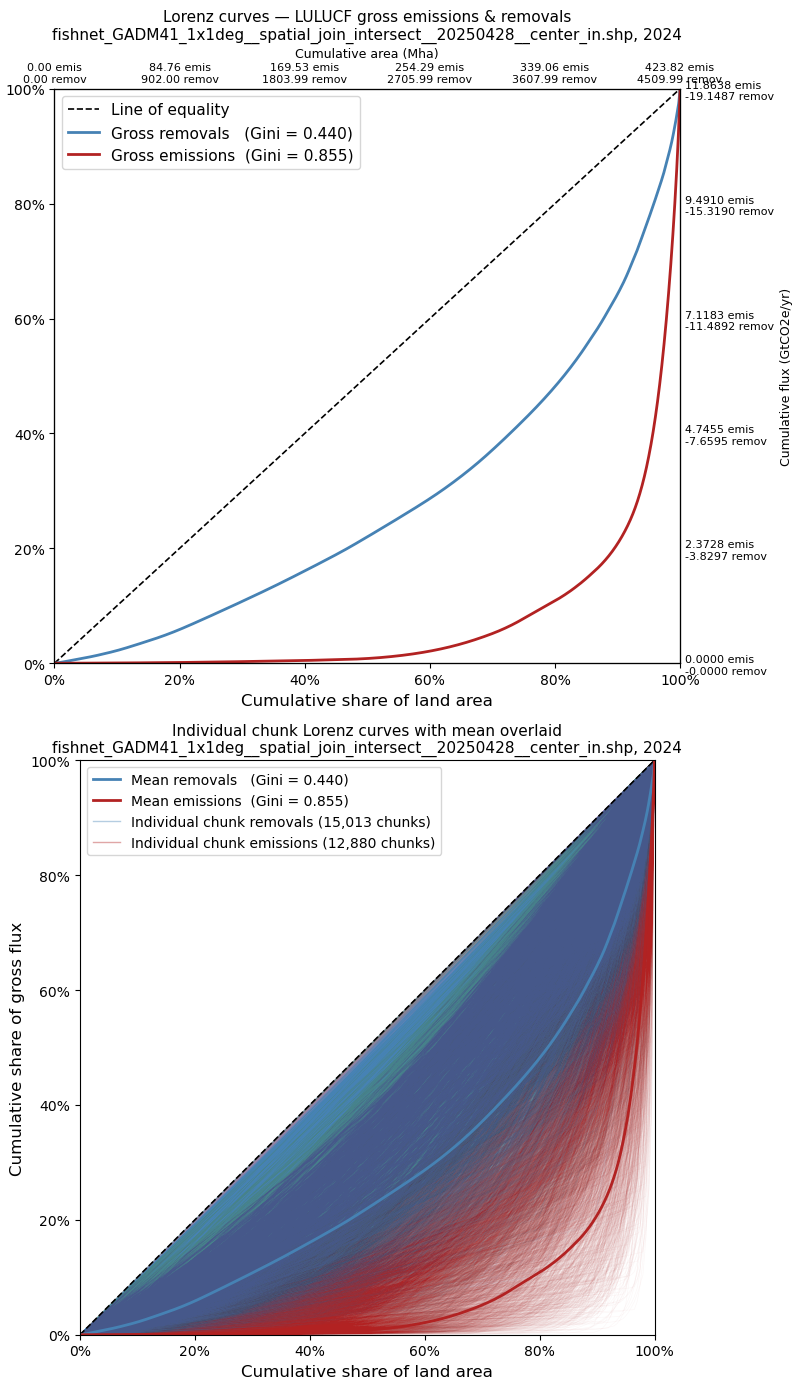

VALIDATION SUMMARY

Year             : 2024
Chunks processed : 18,832  |  missing: 0
Histogram bins   : 10,000  (log 1e-06–1e+05 MgCO2e/ha/yr)
Min valid pixels : 1,000
Chunks in individual curves — emissions: 12,880  removals: 15,013

Land area covered:
  Emitting land         :     423.82 Mha
  Removing land         :    4509.99 Mha

Total fluxes  ← compare against known model output:
  Gross emissions       : +  11.86380 GtCO2e/yr
  Gross removals        : -  19.14873 GtCO2e/yr
  Net (emis − remv)     :    -7.28493 GtCO2e/yr

Concentration — emissions (total: 423.82 Mha, +11.86380 GtCO2e/yr):
  Top 10% most intensive (42.38 Mha) → 79.2% of gross emissions (+9.39387 GtCO2e/yr)
  Top 25% most intensive (105.96 Mha) → 89.2% of gross emissions (+10.58256 GtCO2e/yr)
  Top 50% most intensive (211.91 Mha) → 99.2% of gross emissions (+11.76615 GtCO2e/yr)

Concentration — removals (total: 4509.99 Mha, -19.14873 GtCO2e/yr):
  Top 10% most intensive (451.00 Mha) → 35.7% of gross removals (-6.84

In [23]:
%%time

### Global (or regional) Lorenz curves from 1x1 deg per-ha tiles (serial version-- one chunk at a time, no parallelization)
### Histogram approach: memory-efficient, scalable to global
### Reuses project chunk list utilities from universal_utilities.py
### Two panels: (1) combined global curves, (2) individual chunk curves + mean overlaid
### Per Claude session `Lorenz curves for LULUCF emissions/removals` and 'Lorenz curves for LULUCF emissions/removals, pt2' 

from matplotlib.collections import LineCollection

# ── Configuration ──────────────────────────────────────────────────────────
YEAR = 2024

# Set ONE of the three input modes; set the others to None
SINGLE_CHUNK  = None                        # [W, S, E, N] for one 1x1 deg chunk
# BOUNDING_BOX  = [13, -3, 15, -1]  # W S E N; central Africa 2x2 area
# BOUNDING_BOX  = [10, -10, 20, 0]  # W S E N; central Africa 10x10 area
# BOUNDING_BOX  = [10, -15, 25, 0]  # W S E N; central Africa 15x15 area
# BOUNDING_BOX  = [13, -14, 44, -3]  # W S E N; central Africa large area
BOUNDING_BOX  = None
# SHAPEFILE_URI = None                        # e.g. cn.fishnet_1x1deg_uri for global
SHAPEFILE_URI = cn.fishnet_1x1deg_uri
FIRST_CHUNKS  = None                        # limit to first N chunks (for testing)

N_BINS            = 10_000
INTENSITY_MIN     = 1e-6        # MgCO2e/ha/yr
INTENSITY_MAX     = 1e5         # MgCO2e/ha/yr
MIN_VALID_PIXELS  = 1000        # min valid pixels per chunk to include in individual curves
N_PLOT_POINTS     = 200         # points per individual chunk curve (downsampled)
INDIVIDUAL_ALPHA  = 0.03        # alpha for individual chunk curves

BASE     = ("s3://gfw2-data/climate/AFOLU_flux_model/LULUCF/outputs_vegetation/"
            "version_1_0_5__standard__global")
EMIS_DIR = (f"{BASE}/gross_emissions__all_C_pools__all_gases__MgCO2e/"
            f"annual_intervals/{YEAR}/_ha_yr/4000_pixels/20260130")
REMV_DIR = (f"{BASE}/gross_removals__all_C_pools__MgCO2/"
            f"annual_intervals/{YEAR}/_ha_yr/4000_pixels/20260130")

# ── Build chunk list ───────────────────────────────────────────────────────
if SINGLE_CHUNK is not None:
    chunk_list = [SINGLE_CHUNK]
    area_label = f"chunk {SINGLE_CHUNK}"
elif BOUNDING_BOX is not None:
    chunk_list = uu.get_chunk_bounds_from_bounding_box(BOUNDING_BOX, chunk_size=1.0)
    area_label = f"bbox W={BOUNDING_BOX[0]} S={BOUNDING_BOX[1]} E={BOUNDING_BOX[2]} N={BOUNDING_BOX[3]}"
elif SHAPEFILE_URI is not None:
    fishnet_iso_df = uu.fishnet_with_GADM_iso(SHAPEFILE_URI)
    if FIRST_CHUNKS:
        fishnet_iso_df = fishnet_iso_df[:FIRST_CHUNKS]
    chunk_list = fishnet_iso_df['chunk_id'].apply(uu.process_chunk_id).tolist()
    area_label = SHAPEFILE_URI.split('/')[-1]
else:
    raise ValueError("Set one of SINGLE_CHUNK, BOUNDING_BOX, or SHAPEFILE_URI")

print(f"Chunks to process: {len(chunk_list):,}")

# ── S3 path builder ────────────────────────────────────────────────────────
def chunk_s3_paths(bounds, year, emis_dir, remv_dir):
    w, s, e, n = bounds
    tile_id    = uu.xy_to_tile_id(w, n)
    bounds_str = uu.boundstr(bounds)
    emis = (f"{emis_dir}/{tile_id}__{bounds_str}__"
            f"gross_emissions__all_C_pools__all_gases__MgCO2e_ha_yr_{year}.tif")
    remv = (f"{remv_dir}/{tile_id}__{bounds_str}__"
            f"gross_removals__all_C_pools__MgCO2_ha_yr_{year}.tif")
    return emis, remv

# ── Pixel area (ha) by row for a WGS84 raster ─────────────────────────────
def pixel_area_ha_by_row(src):
    t           = src.transform
    row_idx     = np.arange(src.height)
    lat_centers = t.f + (row_idx + 0.5) * t.e
    d_lat_rad   = abs(t.e) * np.pi / 180
    d_lon_rad   = abs(t.a) * np.pi / 180
    area_km2    = 6371.0**2 * d_lat_rad * d_lon_rad * np.cos(np.deg2rad(lat_centers))
    return area_km2 * 100   # km² → ha

# ── Lorenz curve from histogram ────────────────────────────────────────────
def lorenz_from_histogram(bin_area, bin_flux):
    occupied = (bin_area > 0) | (bin_flux > 0)
    cum_area = np.concatenate([[0.0], np.cumsum(bin_area[occupied])])
    cum_flux = np.concatenate([[0.0], np.cumsum(bin_flux[occupied])])
    return cum_area / cum_area[-1], cum_flux / cum_flux[-1]

def gini(x, y):
    return 1.0 - 2.0 * np.trapezoid(y, x)

# ── Histogram bins (log scale, ascending intensity) ───────────────────────
bin_edges = np.logspace(np.log10(INTENSITY_MIN), np.log10(INTENSITY_MAX), N_BINS + 1)
x_uniform = np.linspace(0, 1, N_PLOT_POINTS)   # shared x grid for downsampled curves

# Global accumulators
emis_bin_area = np.zeros(N_BINS, dtype=np.float64)
emis_bin_flux = np.zeros(N_BINS, dtype=np.float64)
remv_bin_area = np.zeros(N_BINS, dtype=np.float64)
remv_bin_flux = np.zeros(N_BINS, dtype=np.float64)

# Per-chunk curve storage (downsampled y values only; x is shared x_uniform)
chunk_emis_curves = []   # list of 1D arrays, each length N_PLOT_POINTS
chunk_remv_curves = []

n_ok              = 0
n_missing         = 0
n_skipped_emis    = 0
n_skipped_remv    = 0

# ── Main loop: accumulate histogram and store per-chunk curves ─────────────
for bounds in tqdm(chunk_list, desc=f"Processing chunks ({YEAR})"):
    emis_path, remv_path = chunk_s3_paths(bounds, YEAR, EMIS_DIR, REMV_DIR)

    try:
        with rasterio.open(emis_path) as src:
            emis_grid = src.read(1).astype(np.float64)
            areas_1d  = pixel_area_ha_by_row(src)
            area_grid = np.broadcast_to(areas_1d[:, np.newaxis], emis_grid.shape)
        with rasterio.open(remv_path) as src:
            remv_grid = src.read(1).astype(np.float64)
    except Exception:
        n_missing += 1
        continue

    # Per-chunk histogram arrays (temporary)
    c_emis_bin_area = np.zeros(N_BINS, dtype=np.float64)
    c_emis_bin_flux = np.zeros(N_BINS, dtype=np.float64)
    c_remv_bin_area = np.zeros(N_BINS, dtype=np.float64)
    c_remv_bin_flux = np.zeros(N_BINS, dtype=np.float64)

    # Emissions
    emis_mask   = emis_grid > 0
    n_emis_valid = emis_mask.sum()
    if n_emis_valid > 0:
        e_ha      = emis_grid[emis_mask]
        e_ha_area = area_grid[emis_mask]
        e_flux    = e_ha * e_ha_area
        bidx      = np.clip(
            np.searchsorted(bin_edges, e_ha, side='right') - 1, 0, N_BINS - 1
        )
        c_emis_bin_area += np.bincount(bidx, weights=e_ha_area, minlength=N_BINS)
        c_emis_bin_flux += np.bincount(bidx, weights=e_flux,    minlength=N_BINS)

    # Removals
    remv_mask    = remv_grid < 0
    n_remv_valid = remv_mask.sum()
    if n_remv_valid > 0:
        r_ha      = np.abs(remv_grid[remv_mask])
        r_ha_area = area_grid[remv_mask]
        r_flux    = r_ha * r_ha_area
        bidx      = np.clip(
            np.searchsorted(bin_edges, r_ha, side='right') - 1, 0, N_BINS - 1
        )
        c_remv_bin_area += np.bincount(bidx, weights=r_ha_area, minlength=N_BINS)
        c_remv_bin_flux += np.bincount(bidx, weights=r_flux,    minlength=N_BINS)

    # Accumulate into global histograms
    emis_bin_area += c_emis_bin_area
    emis_bin_flux += c_emis_bin_flux
    remv_bin_area += c_remv_bin_area
    remv_bin_flux += c_remv_bin_flux

    # Store per-chunk Lorenz curves if above pixel threshold
    if n_emis_valid >= MIN_VALID_PIXELS:
        cx, cy = lorenz_from_histogram(c_emis_bin_area, c_emis_bin_flux)
        chunk_emis_curves.append(np.interp(x_uniform, cx, cy))
    else:
        n_skipped_emis += 1

    if n_remv_valid >= MIN_VALID_PIXELS:
        cx, cy = lorenz_from_histogram(c_remv_bin_area, c_remv_bin_flux)
        chunk_remv_curves.append(np.interp(x_uniform, cx, cy))
    else:
        n_skipped_remv += 1

    n_ok += 1

print(f"Done — processed: {n_ok:,}  |  missing/skipped: {n_missing:,}")
print(f"Chunks below {MIN_VALID_PIXELS} pixel threshold — "
      f"emissions: {n_skipped_emis:,}  removals: {n_skipped_remv:,}")

# ── Global Lorenz curves ───────────────────────────────────────────────────
emis_x, emis_y = lorenz_from_histogram(emis_bin_area, emis_bin_flux)
remv_x,  remv_y = lorenz_from_histogram(remv_bin_area,  remv_bin_flux)

emis_area_Mha = emis_bin_area.sum() / 1e6
remv_area_Mha = remv_bin_area.sum() / 1e6
emis_flux_Gt  = emis_bin_flux.sum() / 1e9
remv_flux_Gt  = remv_bin_flux.sum() / 1e9

# ── Plot ───────────────────────────────────────────────────────────────────
pct_ticks = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 14))

# ── Panel 1: combined global curves ───────────────────────────────────────
ax1.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Line of equality')
ax1.plot(remv_x,  remv_y,  color='steelblue', lw=2,
         label=f'Gross removals   (Gini = {gini(remv_x, remv_y):.3f})')
ax1.plot(emis_x, emis_y, color='firebrick', lw=2,
         label=f'Gross emissions  (Gini = {gini(emis_x, emis_y):.3f})')

ax1.set_xlabel('Cumulative share of land area', fontsize=12)
ax1.set_ylabel('Cumulative share of gross flux', fontsize=12)
ax1.set_title(
    f'Lorenz curves — LULUCF gross emissions & removals\n{area_label}, {YEAR}',
    fontsize=11
)
ax1.legend(fontsize=11, loc='upper left')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.set_box_aspect(1)

ax_right = ax1.twinx()
ax_top   = ax1.twiny()

ax1.set_xticks(pct_ticks)
ax1.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.set_yticks(pct_ticks)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

ax_right.set_ylim(0, 1)
ax_right.set_yticks(pct_ticks)
ax_right.set_yticklabels(
    [f"{v * emis_flux_Gt:.4f} emis\n{-v * remv_flux_Gt:.4f} remov" for v in pct_ticks],
    fontsize=8
)
ax_right.set_ylabel('Cumulative flux (GtCO2e/yr)', fontsize=9)
ax_right.tick_params(axis='y', length=0)

ax_top.set_xlim(0, 1)
ax_top.set_xticks(pct_ticks)
ax_top.set_xticklabels(
    [f"{v * emis_area_Mha:.2f} emis\n{v * remv_area_Mha:.2f} remov" for v in pct_ticks],
    fontsize=8
)
ax_top.set_xlabel('Cumulative area (Mha)', fontsize=9)
ax_top.tick_params(axis='x', length=0)

# ── Panel 2: individual chunk curves + mean overlaid ──────────────────────
# Individual curves via LineCollection (much faster than individual ax.plot calls)
if chunk_emis_curves:
    segs_emis = [np.column_stack([x_uniform, y]) for y in chunk_emis_curves]
    ax2.add_collection(LineCollection(
        segs_emis, color='firebrick', alpha=INDIVIDUAL_ALPHA, linewidth=0.5
    ))

if chunk_remv_curves:
    segs_remv = [np.column_stack([x_uniform, y]) for y in chunk_remv_curves]
    ax2.add_collection(LineCollection(
        segs_remv, color='steelblue', alpha=INDIVIDUAL_ALPHA, linewidth=0.5
    ))

# Mean curves overlaid in full colour
ax2.plot([0, 1], [0, 1], 'k--', lw=1.2)
ax2.plot(remv_x,  remv_y,  color='steelblue', lw=2,
         label=f'Mean removals   (Gini = {gini(remv_x, remv_y):.3f})')
ax2.plot(emis_x, emis_y, color='firebrick', lw=2,
         label=f'Mean emissions  (Gini = {gini(emis_x, emis_y):.3f})')

# Dummy legend entries for individual curves
ax2.legend(
    handles=[
        ax2.get_lines()[1],   # mean removals
        ax2.get_lines()[2],   # mean emissions
        Line2D([0], [0], color='steelblue', alpha=0.4, lw=1,
               label=f'Individual chunk removals ({len(chunk_remv_curves):,} chunks)'),
        Line2D([0], [0], color='firebrick',  alpha=0.4, lw=1,
               label=f'Individual chunk emissions ({len(chunk_emis_curves):,} chunks)'),
    ],
    fontsize=10, loc='upper left'
)

ax2.set_xlabel('Cumulative share of land area', fontsize=12)
ax2.set_ylabel('Cumulative share of gross flux', fontsize=12)
ax2.set_title(
    f'Individual chunk Lorenz curves with mean overlaid\n{area_label}, {YEAR}',
    fontsize=11
)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.set_xticks(pct_ticks)
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.set_yticks(pct_ticks)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.set_box_aspect(1)

plt.tight_layout()
plt.show()

# ── Validation summary ─────────────────────────────────────────────────────
print("=" * 57)
print("VALIDATION SUMMARY")
print("=" * 57)
print(f"\nYear             : {YEAR}")
print(f"Chunks processed : {n_ok:,}  |  missing: {n_missing:,}")
print(f"Histogram bins   : {N_BINS:,}  (log {INTENSITY_MIN:.0e}–{INTENSITY_MAX:.0e} MgCO2e/ha/yr)")
print(f"Min valid pixels : {MIN_VALID_PIXELS:,}")
print(f"Chunks in individual curves — emissions: {len(chunk_emis_curves):,}  "
      f"removals: {len(chunk_remv_curves):,}")

print(f"\nLand area covered:")
print(f"  Emitting land         : {emis_area_Mha:>10.2f} Mha")
print(f"  Removing land         : {remv_area_Mha:>10.2f} Mha")

print(f"\nTotal fluxes  ← compare against known model output:")
print(f"  Gross emissions       : +{emis_flux_Gt:>10.5f} GtCO2e/yr")
print(f"  Gross removals        : -{remv_flux_Gt:>10.5f} GtCO2e/yr")
print(f"  Net (emis − remv)     : {emis_flux_Gt - remv_flux_Gt:>+11.5f} GtCO2e/yr")

print(f"\nConcentration — emissions (total: {emis_area_Mha:.2f} Mha, +{emis_flux_Gt:.5f} GtCO2e/yr):")
for pct in [10, 25, 50]:
    idx       = np.searchsorted(emis_x, 1 - pct / 100)
    flux_frac = 1 - emis_y[idx]
    print(f"  Top {pct:2d}% most intensive ({pct/100 * emis_area_Mha:.2f} Mha) → "
          f"{100*flux_frac:.1f}% of gross emissions (+{flux_frac * emis_flux_Gt:.5f} GtCO2e/yr)")

print(f"\nConcentration — removals (total: {remv_area_Mha:.2f} Mha, -{remv_flux_Gt:.5f} GtCO2e/yr):")
for pct in [10, 25, 50]:
    idx       = np.searchsorted(remv_x, 1 - pct / 100)
    flux_frac = 1 - remv_y[idx]
    print(f"  Top {pct:2d}% most intensive ({pct/100 * remv_area_Mha:.2f} Mha) → "
          f"{100*flux_frac:.1f}% of gross removals (-{flux_frac * remv_flux_Gt:.5f} GtCO2e/yr)")

print(f"\nGini coefficients:")
print(f"  Gross emissions       : {gini(emis_x, emis_y):.4f}")
print(f"  Gross removals        : {gini(remv_x, remv_y):.4f}")

print(f"\nCurve endpoint check (should both be exactly 1.0):")
print(f"  Emissions             : x={emis_x[-1]:.6f},  y={emis_y[-1]:.6f}")
print(f"  Removals              : x={remv_x[-1]:.6f},  y={remv_y[-1]:.6f}")

In [ ]:
%%time

### Global Lorenz curves from 1x1 deg per-ha gross and gross removals chunks — Coiled parallel version
### Histogram approach: memory-efficient, scalable to global
### Creates two panels: (1) combined global curves, (2) individual chunk curves + mean overlaid
### Per Claude session `Lorenz curves for LULUCF emissions/removals` and 'Lorenz curves for LULUCF emissions/removals, pt2' 
### Create cluster first:
###   python -m src.utilities.create_cluster -n 100 -t 1 -m 8 -cn lorenz_curves

### Haven't tried this yet


# ── Coiled configuration ───────────────────────────────────────────────────
CLUSTER_NAME  = 'lorenz_curves'
N_WORKERS     = 100
WORKER_MEMORY = 8       # GiB — sufficient for per-chunk raster reads
RUN_LOCAL     = False   # True: run serially without Coiled (for testing)
BATCH_SIZE    = 500     # chunks per gather batch; bounds memory on scheduler

# ── Analysis configuration (same as serial cell) ──────────────────────────
YEAR = 2024

SINGLE_CHUNK  = None
BOUNDING_BOX  = None
SHAPEFILE_URI = cn.fishnet_1x1deg_uri   # global run
FIRST_CHUNKS  = None

N_BINS           = 10_000
INTENSITY_MIN    = 1e-6     # MgCO2e/ha/yr
INTENSITY_MAX    = 1e5      # MgCO2e/ha/yr
MIN_VALID_PIXELS = 1000
N_PLOT_POINTS    = 200
INDIVIDUAL_ALPHA = 0.05

BASE     = ("s3://gfw2-data/climate/AFOLU_flux_model/LULUCF/outputs_vegetation/"
            "version_1_0_5__standard__global")
EMIS_DIR = (f"{BASE}/gross_emissions__all_C_pools__all_gases__MgCO2e/"
            f"annual_intervals/{YEAR}/_ha_yr/4000_pixels/20260130")
REMV_DIR = (f"{BASE}/gross_removals__all_C_pools__MgCO2/"
            f"annual_intervals/{YEAR}/_ha_yr/4000_pixels/20260130")

# ── Build chunk list ───────────────────────────────────────────────────────
if SINGLE_CHUNK is not None:
    chunk_list = [SINGLE_CHUNK]
    area_label = f"chunk {SINGLE_CHUNK}"
elif BOUNDING_BOX is not None:
    chunk_list = uu.get_chunk_bounds_from_bounding_box(BOUNDING_BOX, chunk_size=1.0)
    area_label = f"bbox W={BOUNDING_BOX[0]} S={BOUNDING_BOX[1]} E={BOUNDING_BOX[2]} N={BOUNDING_BOX[3]}"
elif SHAPEFILE_URI is not None:
    fishnet_iso_df = uu.fishnet_with_GADM_iso(SHAPEFILE_URI)
    if FIRST_CHUNKS:
        fishnet_iso_df = fishnet_iso_df[:FIRST_CHUNKS]
    chunk_list = fishnet_iso_df['chunk_id'].apply(uu.process_chunk_id).tolist()
    area_label = SHAPEFILE_URI.split('/')[-1]
else:
    raise ValueError("Set one of SINGLE_CHUNK, BOUNDING_BOX, or SHAPEFILE_URI")

print(f"Chunks to process: {len(chunk_list):,}")

# ── Worker function ────────────────────────────────────────────────────────
def process_chunk_lorenz(bounds, year, emis_dir, remv_dir,
                          n_bins, intensity_min, intensity_max,
                          min_valid_pixels, n_plot_points):
    """
    Processes one 1x1 deg chunk on a Coiled worker.
    Returns partial histogram accumulators and a downsampled Lorenz curve.
    All imports are local so the function is self-contained on the worker.
    bin_edges reconstructed from scalars to avoid serialising a large array
    for every task submission.
    """
    import numpy as np
    import rasterio
    from src.utilities import universal_utilities as uu

    w, s, e, n = bounds
    tile_id    = uu.xy_to_tile_id(w, n)
    bounds_str = uu.boundstr(bounds)
    emis_path  = (f"{emis_dir}/{tile_id}__{bounds_str}__"
                  f"gross_emissions__all_C_pools__all_gases__MgCO2e_ha_yr_{year}.tif")
    remv_path  = (f"{remv_dir}/{tile_id}__{bounds_str}__"
                  f"gross_removals__all_C_pools__MgCO2_ha_yr_{year}.tif")

    bin_edges = np.logspace(np.log10(intensity_min), np.log10(intensity_max), n_bins + 1)
    x_uniform = np.linspace(0, 1, n_plot_points)

    def pixel_area_ha_by_row(src):
        t           = src.transform
        row_idx     = np.arange(src.height)
        lat_centers = t.f + (row_idx + 0.5) * t.e
        d_lat_rad   = abs(t.e) * np.pi / 180
        d_lon_rad   = abs(t.a) * np.pi / 180
        area_km2    = 6371.0**2 * d_lat_rad * d_lon_rad * np.cos(np.deg2rad(lat_centers))
        return area_km2 * 100

    def lorenz_from_histogram(bin_area, bin_flux):
        occupied = (bin_area > 0) | (bin_flux > 0)
        if not occupied.any():
            return None, None
        cum_area = np.concatenate([[0.0], np.cumsum(bin_area[occupied])])
        cum_flux = np.concatenate([[0.0], np.cumsum(bin_flux[occupied])])
        if cum_area[-1] == 0 or cum_flux[-1] == 0:
            return None, None
        return cum_area / cum_area[-1], cum_flux / cum_flux[-1]

    result = {
        'emis_bin_area': np.zeros(n_bins),
        'emis_bin_flux': np.zeros(n_bins),
        'remv_bin_area': np.zeros(n_bins),
        'remv_bin_flux': np.zeros(n_bins),
        'n_emis_valid' : 0,
        'n_remv_valid' : 0,
        'chunk_emis_y' : None,
        'chunk_remv_y' : None,
        'status'       : 'ok',
    }

    try:
        with rasterio.open(emis_path) as src:
            emis_grid = src.read(1).astype(np.float64)
            areas_1d  = pixel_area_ha_by_row(src)
            area_grid = np.broadcast_to(areas_1d[:, np.newaxis], emis_grid.shape)
        with rasterio.open(remv_path) as src:
            remv_grid = src.read(1).astype(np.float64)
    except Exception as ex:
        result['status'] = f'missing: {ex}'
        return result

    # Emissions
    emis_mask = emis_grid > 0
    n_emis    = int(emis_mask.sum())
    result['n_emis_valid'] = n_emis
    if n_emis > 0:
        e_ha      = emis_grid[emis_mask]
        e_ha_area = area_grid[emis_mask]
        e_flux    = e_ha * e_ha_area
        bidx      = np.clip(
            np.searchsorted(bin_edges, e_ha, side='right') - 1, 0, n_bins - 1
        )
        result['emis_bin_area'] += np.bincount(bidx, weights=e_ha_area, minlength=n_bins)
        result['emis_bin_flux'] += np.bincount(bidx, weights=e_flux,    minlength=n_bins)
        if n_emis >= min_valid_pixels:
            cx, cy = lorenz_from_histogram(result['emis_bin_area'], result['emis_bin_flux'])
            if cx is not None:
                result['chunk_emis_y'] = np.interp(x_uniform, cx, cy)

    # Removals
    remv_mask = remv_grid < 0
    n_remv    = int(remv_mask.sum())
    result['n_remv_valid'] = n_remv
    if n_remv > 0:
        r_ha      = np.abs(remv_grid[remv_mask])
        r_ha_area = area_grid[remv_mask]
        r_flux    = r_ha * r_ha_area
        bidx      = np.clip(
            np.searchsorted(bin_edges, r_ha, side='right') - 1, 0, n_bins - 1
        )
        result['remv_bin_area'] += np.bincount(bidx, weights=r_ha_area, minlength=n_bins)
        result['remv_bin_flux'] += np.bincount(bidx, weights=r_flux,    minlength=n_bins)
        if n_remv >= min_valid_pixels:
            cx, cy = lorenz_from_histogram(result['remv_bin_area'], result['remv_bin_flux'])
            if cx is not None:
                result['chunk_remv_y'] = np.interp(x_uniform, cx, cy)

    return result

# ── Connect to cluster (or fall back to local) ─────────────────────────────
cluster, client, run_local = uu.connect_to_Coiled_cluster(
    CLUSTER_NAME, RUN_LOCAL, fallback_to_local_on_failure=False
)

# If no running cluster found, create one
if cluster is None and not RUN_LOCAL:
    print(f"No running cluster '{CLUSTER_NAME}' found — creating one...")
    cluster = cc_create_cluster(CLUSTER_NAME, N_WORKERS, WORKER_MEMORY, threads_per_worker=1)
    client  = Client(cluster)
    print(f"Cluster ready: {cluster.dashboard_link}")

# ── Global accumulators ────────────────────────────────────────────────────
emis_bin_area  = np.zeros(N_BINS, dtype=np.float64)
emis_bin_flux  = np.zeros(N_BINS, dtype=np.float64)
remv_bin_area  = np.zeros(N_BINS, dtype=np.float64)
remv_bin_flux  = np.zeros(N_BINS, dtype=np.float64)
chunk_emis_curves = []
chunk_remv_curves = []
x_uniform      = np.linspace(0, 1, N_PLOT_POINTS)
n_ok           = 0
n_missing      = 0
n_skipped_emis = 0
n_skipped_remv = 0

# ── Shared task kwargs ─────────────────────────────────────────────────────
task_kwargs = dict(
    year          = YEAR,
    emis_dir      = EMIS_DIR,
    remv_dir      = REMV_DIR,
    n_bins        = N_BINS,
    intensity_min = INTENSITY_MIN,
    intensity_max = INTENSITY_MAX,
    min_valid_pixels = MIN_VALID_PIXELS,
    n_plot_points = N_PLOT_POINTS,
)

def _aggregate(result):
    """Aggregate one worker result into global accumulators."""
    global n_ok, n_missing, n_skipped_emis, n_skipped_remv
    if result['status'] != 'ok':
        n_missing += 1
        return
    emis_bin_area += result['emis_bin_area']
    emis_bin_flux += result['emis_bin_flux']
    remv_bin_area += result['remv_bin_area']
    remv_bin_flux += result['remv_bin_flux']
    if result['chunk_emis_y'] is not None:
        chunk_emis_curves.append(result['chunk_emis_y'])
    else:
        n_skipped_emis += 1
    if result['chunk_remv_y'] is not None:
        chunk_remv_curves.append(result['chunk_remv_y'])
    else:
        n_skipped_remv += 1
    n_ok += 1

# ── Process: Coiled (parallel) or local (serial) ───────────────────────────
chunk_batches = [chunk_list[i:i + BATCH_SIZE]
                 for i in range(0, len(chunk_list), BATCH_SIZE)]

if client is not None:
    # ── Coiled parallel path ───────────────────────────────────────────────
    print(f"Submitting {len(chunk_list):,} chunks in "
          f"{len(chunk_batches)} batches of {BATCH_SIZE}...")

    for i, batch in enumerate(chunk_batches):
        futures = [
            client.submit(
                process_chunk_lorenz,
                bounds,
                **task_kwargs,
                key=f"lorenz-{int(bounds[0])}_{int(bounds[1])}_{int(bounds[2])}_{int(bounds[3])}"
            )
            for bounds in batch
        ]

        for future in tqdm(
            as_completed(futures),
            total=len(futures),
            desc=f"Batch {i+1}/{len(chunk_batches)}"
        ):
            try:
                _aggregate(future.result())
            except Exception as ex:
                n_missing += 1
                print(f"  Future failed: {ex}")

else:
    # ── Local serial path ──────────────────────────────────────────────────
    print("Running locally (no Coiled cluster)...")
    for bounds in tqdm(chunk_list, desc=f"Processing chunks ({YEAR})"):
        result = process_chunk_lorenz(bounds, **task_kwargs)
        _aggregate(result)

print(f"\nDone — processed: {n_ok:,}  |  missing/skipped: {n_missing:,}")
print(f"Chunks below {MIN_VALID_PIXELS} pixel threshold — "
      f"emissions: {n_skipped_emis:,}  removals: {n_skipped_remv:,}")

# ── Lorenz curves, plots, validation ──────────────────────────────────────
# (identical to serial cell from here — paste in the lorenz_from_histogram,
#  gini, plot, and validation blocks from the serial cell)

def lorenz_from_histogram(bin_area, bin_flux):
    occupied = (bin_area > 0) | (bin_flux > 0)
    cum_area = np.concatenate([[0.0], np.cumsum(bin_area[occupied])])
    cum_flux = np.concatenate([[0.0], np.cumsum(bin_flux[occupied])])
    return cum_area / cum_area[-1], cum_flux / cum_flux[-1]

def gini(x, y):
    return 1.0 - 2.0 * np.trapezoid(y, x)

emis_x, emis_y = lorenz_from_histogram(emis_bin_area, emis_bin_flux)
remv_x,  remv_y = lorenz_from_histogram(remv_bin_area,  remv_bin_flux)

emis_area_Mha = emis_bin_area.sum() / 1e6
remv_area_Mha = remv_bin_area.sum() / 1e6
emis_flux_Gt  = emis_bin_flux.sum() / 1e9
remv_flux_Gt  = remv_bin_flux.sum() / 1e9

# ── Panel 1: combined global curves ───────────────────────────────────────
pct_ticks = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 14))

ax1.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Line of equality')
ax1.plot(remv_x,  remv_y,  color='steelblue', lw=2,
         label=f'Gross removals   (Gini = {gini(remv_x, remv_y):.3f})')
ax1.plot(emis_x, emis_y, color='firebrick', lw=2,
         label=f'Gross emissions  (Gini = {gini(emis_x, emis_y):.3f})')
ax1.set_xlabel('Cumulative share of land area', fontsize=12)
ax1.set_ylabel('Cumulative share of gross flux', fontsize=12)
ax1.set_title(
    f'Lorenz curves — LULUCF gross emissions & removals\n{area_label}, {YEAR}',
    fontsize=11
)
ax1.legend(fontsize=11, loc='upper left')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.set_box_aspect(1)

ax_right = ax1.twinx()
ax_top   = ax1.twiny()
ax1.set_xticks(pct_ticks)
ax1.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.set_yticks(pct_ticks)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax_right.set_ylim(0, 1)
ax_right.set_yticks(pct_ticks)
ax_right.set_yticklabels(
    [f"{v * emis_flux_Gt:.4f} emis\n{-v * remv_flux_Gt:.4f} remov" for v in pct_ticks],
    fontsize=8
)
ax_right.set_ylabel('Cumulative flux (GtCO2e/yr)', fontsize=9)
ax_right.tick_params(axis='y', length=0)
ax_top.set_xlim(0, 1)
ax_top.set_xticks(pct_ticks)
ax_top.set_xticklabels(
    [f"{v * emis_area_Mha:.2f} emis\n{v * remv_area_Mha:.2f} remov" for v in pct_ticks],
    fontsize=8
)
ax_top.set_xlabel('Cumulative area (Mha)', fontsize=9)
ax_top.tick_params(axis='x', length=0)

# ── Panel 2: individual chunk curves + mean overlaid ──────────────────────
if chunk_emis_curves:
    segs = [np.column_stack([x_uniform, y]) for y in chunk_emis_curves]
    ax2.add_collection(LineCollection(
        segs, color='firebrick', alpha=INDIVIDUAL_ALPHA, linewidth=0.5
    ))
if chunk_remv_curves:
    segs = [np.column_stack([x_uniform, y]) for y in chunk_remv_curves]
    ax2.add_collection(LineCollection(
        segs, color='steelblue', alpha=INDIVIDUAL_ALPHA, linewidth=0.5
    ))
ax2.plot([0, 1], [0, 1], 'k--', lw=1.2)
ax2.plot(remv_x,  remv_y,  color='steelblue', lw=2,
         label=f'Mean removals   (Gini = {gini(remv_x, remv_y):.3f})')
ax2.plot(emis_x, emis_y, color='firebrick', lw=2,
         label=f'Mean emissions  (Gini = {gini(emis_x, emis_y):.3f})')
ax2.legend(
    handles=[
        ax2.get_lines()[1],
        ax2.get_lines()[2],
        Line2D([0], [0], color='steelblue', alpha=0.4, lw=1,
               label=f'Individual chunk removals ({len(chunk_remv_curves):,} chunks)'),
        Line2D([0], [0], color='firebrick',  alpha=0.4, lw=1,
               label=f'Individual chunk emissions ({len(chunk_emis_curves):,} chunks)'),
    ],
    fontsize=10, loc='upper left'
)
ax2.set_xlabel('Cumulative share of land area', fontsize=12)
ax2.set_ylabel('Cumulative share of gross flux', fontsize=12)
ax2.set_title(
    f'Individual chunk Lorenz curves with mean overlaid\n{area_label}, {YEAR}',
    fontsize=11
)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.set_xticks(pct_ticks)
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.set_yticks(pct_ticks)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.set_box_aspect(1)

plt.tight_layout()
plt.show()

# ── Validation summary ─────────────────────────────────────────────────────
print("=" * 57)
print("VALIDATION SUMMARY")
print("=" * 57)
print(f"\nYear             : {YEAR}")
print(f"Chunks processed : {n_ok:,}  |  missing: {n_missing:,}")
print(f"Histogram bins   : {N_BINS:,}  (log {INTENSITY_MIN:.0e}–{INTENSITY_MAX:.0e} MgCO2e/ha/yr)")
print(f"Min valid pixels : {MIN_VALID_PIXELS:,}")
print(f"Chunks in individual curves — emissions: {len(chunk_emis_curves):,}  "
      f"removals: {len(chunk_remv_curves):,}")

print(f"\nLand area covered:")
print(f"  Emitting land         : {emis_area_Mha:>10.2f} Mha")
print(f"  Removing land         : {remv_area_Mha:>10.2f} Mha")

print(f"\nTotal fluxes  ← compare against known model output:")
print(f"  Gross emissions       : +{emis_flux_Gt:>10.5f} GtCO2e/yr")
print(f"  Gross removals        : -{remv_flux_Gt:>10.5f} GtCO2e/yr")
print(f"  Net (emis − remv)     : {emis_flux_Gt - remv_flux_Gt:>+11.5f} GtCO2e/yr")

print(f"\nConcentration — emissions (total: {emis_area_Mha:.2f} Mha, +{emis_flux_Gt:.5f} GtCO2e/yr):")
for pct in [10, 25, 50]:
    idx       = np.searchsorted(emis_x, 1 - pct / 100)
    flux_frac = 1 - emis_y[idx]
    print(f"  Top {pct:2d}% most intensive ({pct/100 * emis_area_Mha:.2f} Mha) → "
          f"{100*flux_frac:.1f}% of gross emissions (+{flux_frac * emis_flux_Gt:.5f} GtCO2e/yr)")

print(f"\nConcentration — removals (total: {remv_area_Mha:.2f} Mha, -{remv_flux_Gt:.5f} GtCO2e/yr):")
for pct in [10, 25, 50]:
    idx       = np.searchsorted(remv_x, 1 - pct / 100)
    flux_frac = 1 - remv_y[idx]
    print(f"  Top {pct:2d}% most intensive ({pct/100 * remv_area_Mha:.2f} Mha) → "
          f"{100*flux_frac:.1f}% of gross removals (-{flux_frac * remv_flux_Gt:.5f} GtCO2e/yr)")

print(f"\nGini coefficients:")
print(f"  Gross emissions       : {gini(emis_x, emis_y):.4f}")
print(f"  Gross removals        : {gini(remv_x, remv_y):.4f}")

print(f"\nCurve endpoint check (should both be exactly 1.0):")
print(f"  Emissions             : x={emis_x[-1]:.6f},  y={emis_y[-1]:.6f}")
print(f"  Removals              : x={remv_x[-1]:.6f},  y={remv_y[-1]:.6f}")

# ── Shut down cluster when done ────────────────────────────────────────────
if cluster is not None:
    print("\nShutting down cluster...")
    client.close()
    cluster.shutdown()